# Homework 4: Big Data and Google Cloud

UIC CS 418, Spring 2025

_According to the **Academic Integrity Policy** of this course, all work submitted for grading must be done individually, unless otherwise specified. While we encourage you to talk to your peers and learn from them, this interaction must be superficial with regards to all work submitted for grading. This means you cannot work in teams, you cannot work side-by-side, you cannot submit someone else’s work (partial or complete) as your own. In particular, note that you are guilty of academic dishonesty if you extend or receive any kind of unauthorized assistance. Absolutely no transfer of program code between students is permitted (paper or electronic), and you may not solicit code from family, friends, or online forums. Other examples of academic dishonesty include emailing your program to another student, copying-pasting code from the internet, working in a group on a homework assignment, and allowing a tutor, TA, or another individual to write an answer for you. Academic dishonesty is unacceptable, and penalties range from failure to expulsion from the university; cases are handled via the official student conduct process described at https://dos.uic.edu/conductforstudents.shtml._

_Authorship effort on any submitted work must be accurately documented. Artificial Intelligence tools like ChatGPT represent a new paradigm in academic learning. Their use is permitted for this assignment but should be used with caution. These systems often make mistakes and are best used when incorporated with user knowledge and experience, so try to actually learn the material in order to use these tools effectively. The main ideas and authorship of submitted work should be yours and the help must be clearly documented. At the end of this assignment, you are asked to write a "Use of AI tools statement." You may want to look at the format of this statement before you start working on the homework, in order to understand what docomentation you are expected to provide._

This homework is an individual assignment for all graduate students. Undergraduate students are allowed to work in pairs and submit one homework assignment per pair. There will be no extra credit given to undergraduate students who choose to work alone. The pairs of students who choose to work together and submit one homework assignment together still need to abide by the Academic Integrity Policy and not share or receive help from others (except each other).


## Due Date

This assignment is due at 11:59pm on April 25th, 2025.


### Instructions

You need to complete all code and answer all questions denoted by **Q#** in this notebook. When you are done, you should export **`hw4.ipynb`** with your answers as a PDF file, upload that file `hw4.pdf` to *Homework 4 - written* on Gradescope, tagging each question. 

Select your submission subdirectory `sub` and your completed Jupyter notebook (`hw4.ipynb` file) and zip it. As a result your `sub` subdirectory and `hw4.ipynb` file should be in the root of your zip file. Upload this zip file to *Homework 4 - code* on Gradescope. 

For undergraduate students who work in a team of two, only one student needs to submit the homework and just tag the other student on Gradescope.

**Keep an eye out for the following icons:**



<img src="./icons/edit.png" width="20px" heigh="20px" align="left">  Specifies that you need to add something to the notebook in order to get credit.


<img src="./icons/save.png" width="20px" height="20px" align="left">  Specifies that you need to save something to `sub` (submission) subdirectory or verify the existence of some file in `sub` to get credit.



<img src="./icons/warning.png" width="20px" height="20px" align="left">  Warnings to avoid common mistakes and pitfalls. Pay special attention to these.




#### Autograding

Q3 and Q4 will be graded based on your PDF submission, the rest of the questions will be graded using an Autograder. 

## Before We Start

Before we dive into the assignment, we need to install the following python packages:

- seaborn*
- matplotlib*
- nltk*
- sklearn*
- pandas*
- numpy*
- google-cloud
- google-cloud-storage
- bigquery-magics
- google-cloud-bigquery[pandas]

Packages marked with * should be pre-installed in a conda environment. You may install missing packages one at a time using `pip` command or you can run the following shell command to install them all at once:

In [246]:
!pip install -r ./requirements.txt > pip-log.txt


<img src="./icons/warning.png" width="20px" height="20px" align="left"> If you are installing using the shell command listed above then pay attention to any warnings and check the logs `pip-log.txt`.

Now, we are ready to import all dependencies.

In [248]:
from google.cloud import storage
import seaborn as sns
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np
import json
import os

%load_ext bigquery_magics

The bigquery_magics extension is already loaded. To reload it, use:
  %reload_ext bigquery_magics


We also need to ensure that we have required nltk packages installed:

In [250]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/rahinjain/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /Users/rahinjain/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/rahinjain/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

Now that we have everything we need, we can dive into the homework itself.

## Cloud Services

Most real world systems in the modern world generate copious amount of data (billions of records) and in order to process this data and to enable reasoning through statistical models, we need high computational power and memory which is not available in most personal machines.

One solution is to build and maintain your own cluster of high-end machines which has a massive overhead and cost associated with it, which is definitely not suitable for individuals or small teams. Hence, most individuals and companies rely on cloud service providers for a range of services, including but not limited to storage, processing, querying and visualizing large datasets.

In this homework, we will use [Google Cloud](https://cloud.google.com/) to query and visualize data and we will train and deploy a machine learning model in the cloud. The rest of the homework is divided in 5 parts.

**Part 0:** Setup: Initial configurations

**Part 1:** Big Query: A database for Big Data

**Part 2:** Data Studio: A visualization tool for Big Data

**Part 3:** Vertex AI: Machine Learning with Big Data

**Part 4**: Statement on the use of AI tools

These services can save a lot of time and make your life easier when handling a large amount of data which cannot be processed using a single machine. So let's get started!

## Part 0: Setup


### Setup Billing
Follow this [link](https://vector.my.salesforce-sites.com/GCPEDU?cid=BWpCid%2FSWC32sE2yIQahb29v%2BYBmL3VWkJMjDJFvRht4zIUhYYgtPYg3TS%2Fc6TsB/) to claim \\$50 credit using your @uic.edu email. This homework can be completed while utilizing less than \\$5. Fill up the details in following form and it will send you an email to verify your account.

<img src='./screenshots/credit/00-first-form.png'>

After you have received your verification email (shown below), follow the link in email to request a coupon 

<img src='./screenshots/credit/01-verification-email.png'>

You will receive a coupon in an email as shown below, follow the link to redeem it.

<img src='./screenshots/credit/02-coupon.png'>

<img src="./icons/warning.png" width="20px" height="20px" align="left"><font color="red"> Once you have received the email with the code above, you can redeem it with your UIC email or your personal gmail account.</font>

<img src='./screenshots/credit/00-coupon_redeem_mail.png'>

Once you accept and add credit to your account, you will be sent to the following page (Navigation Menu -> Billing -> Overview).

<img src='./screenshots/credit/03-verify-credit.png'>

Verify that \$50 have been added to your billing account "Billing Account for Education" (default name) with credit name "CS 418 Introduction to Data Science jan24". You can check the credit by choosing the "Credits" menu.

<img src='./screenshots/credit/04-verify-credit.png'>


### Create Project

Google Cloud provides a common interface to manage and monitor all projects, this is called Google Cloud Console. First, you need to log into [Google Cloud Console](https://console.cloud.google.com/) using the account with which you redeemed your credits..

After logging in, choose the menu option from the top left corner and select Cloud overview -> Dashboard as shown in the below image.

<img src='./screenshots/misc/welcome.png'>


Click on the "CREATE PROJECT".

<img src='./screenshots/misc/00-select-project.png'>

Now you it will take you to the project form:

<img src="./screenshots/misc/01-name-project.png">


Name your project `homework4` and click *CREATE* button to set up your project.

All the Google Cloud services are offered within the context of a project and once the project is created, you will be redirected to project dashboard (or Google Cloud Console) where you can add services to the project, monitor activity and manage billing etc.

<img src="./screenshots/misc/02-project-dashboard.png">

### Link Billing Account

Before, we proceed, we need to link a billing account to our project or verify that the previously created billing account is linked to our project automatically. First, ensure that the correct project is selected, then open the left sidebar menu using the button on top-left and select Billing.

<img src="./screenshots/credit/00-link-billing.png">

This will take you to a screen which specifies the billing account linked to your project. Verify that the linked account is "Billing Account for Education" with \$50 credits for "CS 418 Introduction to Data Science spring25".

<img src="./icons/warning.png" width="20px" height="20px" align="left"> <font color='red'> You might have multiple billing accounts, as shown in the image below, in that case, make sure that the correct account is linked to avoid any unnecessary cost.</font>

<img src="./screenshots/credit/01-multiple-billing.png">

Now that our project is setup, let's add a service to it!

### Adding a Bucket

A bucket is just a storage container, it serves the same purpose as a cloud storage service (e.g. *Google Drive*) but it is more suitable for programmatic access and integration with other services as we will see later. Buckets are managed through a service *Cloud Storage* and we can add a bucket to our project through the sidebar (topleft menu) as shown in the following image:

<img src="./screenshots/bucket/00-select-storage.png" />

Before you add any service, make sure that your active project is the one you just created(homework4). Then you can select the sidebar menu by clicking on the top-left button and add services from the menu.

<img src="./icons/warning.png" width="20px" height="20px" align="left">   <font color='red'>Adding services may incur a high cost so only add what you need.</font>

Selecting *Buckets* will take you to the following screen:

<img src="./screenshots/bucket/01-select-create.png" />

Click on the *CREATE* button as shown above and you will be taken to the following form:

<img width="600" height="800" src="./screenshots/bucket/01-create-bucket-name.png"/>
<img width="600" height="800" src="./screenshots/bucket/02-create-bucket-location.png"/>
<img width="600" height="800" src="./screenshots/bucket/03-create-bucket-type.png"/>
<img width="600" height="800" src="./screenshots/bucket/04-create-bucket-granularity.png"/>
<img width="600" height="800" src="./screenshots/bucket/05-create-bucket-security.png"/>


Fill out the form as shown above (use the provided links to learn more about these fields), however you need to enter a unique bucket name and press create. Now you should be able to view your bucket in a file browser like environment. We will come back to this later, first, let's set up authentication first so that we can communicate with Google Cloud.

### Setup Authentication

We will follow the simple steps listed in this tutorial ([Authentication tutorial](https://cloud.google.com/docs/authentication/getting-started)) to setup authentication.

First, we need to setup a service account. Navigate to "IAM & Admin -> Service Accounts". 

<img src="./screenshots/misc/00-auth-setup.png">

Choose "CREATE SERVICE ACCOUNT" acccording to the following image.

<img src="./screenshots/misc/00(1)-auth-setup.png">

Fill up the form as shown below. When the service account is created, the JSON key file will be downloaded. Rename your JSON key file as `homework4-key.json` and **copy it in homework root directory as** `homework4-key.json`.

<img src="./screenshots/misc/00(2)-auth-setup.png">
<img src="./screenshots/misc/01-auth-setup.png">
<img src="./screenshots/misc/02-auth-setup.png">
<img src="./screenshots/misc/03-auth-setup.png">

We can now setup an enviornment variable `GOOGLE_APPLICATION_CREDENTIALS` using the following python command, this enables the google cloud API to use the JSON key while making requests.

In [261]:
os.environ['GOOGLE_APPLICATION_CREDENTIALS'] = 'homework4-key.json'

Now, we can test our setup by making an authenticated API call to list buckets.

In [264]:
def list_buckets():
    storage_client = storage.Client()
    # Make an authenticated API request
    buckets = list(storage_client.list_buckets())
    print(buckets)

    
list_buckets()
# The expected output of this command should contain the name of your bucket
# [<Bucket: [YOUR BUCKET NAME]>]

[<Bucket: cloud-ai-platform-30d7040a-e6d4-46e9-9f06-66ec2945ce8b>, <Bucket: edu-uic-cs418-rahinjain-homework4>]


Using this JSON key, we can now communicate with server without having to explicitly log in.

<img src="./icons/warning.png" width="20px" height="20px" align="left">   `homework4-key.json` contains sensitive information that you should not share with anyone. Do not submit this file.

## Part 1: BigQuery

BigQuery is a large scale database which can process multiple GBs of data (e.g. all crime records in Chicago since 2001) within just a few seconds and provides the capacity to store and retrieve structured information which can either be used by your application or another cloud service. You can read more about it on the [project page](https://cloud.google.com/bigquery/).

One of the key strenghts of BigQuery is that it supports Structured Query Language (SQL) which is the de facto query language for Relational Databases in which data is stored in tabular form (just like pandas! but not in-memory). This enables the developers to query large databases without having to learn a new language, however, if you are not familiar with SQL or a simple refresher course then you can get a quick introduction at [W3 Schools](https://www.w3schools.com/sql/). 

Let's first go to BigQuery interface and explore some large scale public datasets. From the [project dashboard](https://console.cloud.google.com) select BigQuery from the sidebar:

<img src="./screenshots/bquery/01-select-bigquery.png" />


This will take you to the BigQuery interface. For this homework, we will be using publicly available chicago crime data which encompasses crime records in Chicago since 2001. It is already structured, cleaned and maintained by Google and we can just directly query it, however we can also add our own datasets to BigQuery if needed.

<img src="./screenshots/bquery/00-bigquery-data.png" />
<img src="./screenshots/bquery/00(1)-bigquery-data.png" />

Browse and select the table from the sidebar as shown in the figure and you will be able to see all the fields in the table and their description. You can also select *Preview* to show a subset of the dataset.

<img src="./screenshots/bquery/02-select-table.png" />


Let's run this simple query using the Query Editor

```
#standardSQL

SELECT * FROM `bigquery-public-data.chicago_crime.crime`
WHERE primary_type = "THEFT"
LIMIT 100;
```

This query will select the top 100 crime records of type theft form the crime dataset.

<img src="./icons/warning.png" width="20px" height="20px" align="left"> **\`** or backtick is a character which is not the same as an apostrophe or double quotes and is often used in SQL.

<img src="./icons/warning.png" width="20px" height="20px" align="left"> You always need to enter the prefix of the table or the dataset identifier *bigquery-public-data.chicago_crime* to access *crime* table.


<img src="./screenshots/bquery/03-query-results.png" />

In the figure above, you can see the results listed as a table. You can also export results in CSV format or explore them in Data Studio (a visualization portal that we will discuss later). Just like `pandas`, you may also perform a Group By operation and order the results using the following query:

```
SELECT primary_type, COUNT(*) as count FROM `bigquery-public-data.chicago_crime.crime`
GROUP BY primary_type
ORDER BY count;
```

The results are as follows:

<img src="./screenshots/bquery/04-query-group.png" />

## Q1 (20%)

<img src="./icons/edit.png" width="20px" height="20px" align="left"> Write an SQL query to extract the number of domestic/not-domestic cases per primary type for cases that didn't end up with an arrest, exclude "OTHER OFFENSE" and all non-criminal types, only consider records until the end of year 2023 and sort the results in ascending order by primary type and domestic.

<img src="./icons/save.png" width="20px" height="20px" align="left"> Take a screenshot (full screen, png format), rename it as `q1-results.png` and store it in `sub` subdirectory.

<img src="./icons/edit.png" width="20px" height="20px" align="left"> Include screenshot in the notebook by editing the following markdown (if needed). It shows as a broken image by default if screenshot is unavailable.

<img src="sub/q1-results.png" align="center"/>

<br/>
<br/>

<img src="./icons/warning.png" width="20px" height="20px" align="left"><font color="red"> Refresh your browser if it does not appear right away.</font>

Since `pandas` and SQL operate on tables and offer similar functionality, we can transfer SQL results to a `pandas` data frame for further processing. One arduous way to do it is to first export results from BigQuery interface as a CSV file and load it in pandas, but there is a much better and convenient method available through the `bigquery` magic command. The following statement will run a query on the server and store results in the specified `df` dataframe, while running it shows the time elapsed.

In [338]:
%%bigquery df

-- This is an SQL comment


SELECT * FROM `bigquery-public-data.chicago_crime.crime`
WHERE primary_type = "THEFT"
LIMIT 100;

Query is running:   0%|          |

Downloading:   0%|          |

In [340]:
# We can now print a subset of these results using this familiar method
df.head()

,unique_key,case_number,date,block,iucr,primary_type,description,location_description,arrest,domestic,...,ward,community_area,fbi_code,x_coordinate,y_coordinate,year,updated_on,latitude,longitude,location
0,7738478,HS546847,2010-10-03 11:00:00+00:00,006XX W MONROE ST,0810,THEFT,OVER $500,PARKING LOT/GARAGE(NON.RESID.),False,False,...,42,28,06,1172186.0,1899815.0,2010,2018-02-10 15:50:01+00:00,41.880542,-87.643207,"(41.880541742, -87.643207263)"
1,5979912,HN776854,2007-12-24 14:00:00+00:00,001XX N JEFFERSON ST,0810,THEFT,OVER $500,PARKING LOT/GARAGE(NON.RESID.),False,False,...,42,28,06,1172312.0,1900935.0,2007,2018-02-28 15:56:25+00:00,41.883612,-87.642712,"(41.883612314, -87.642711511)"
2,4257894,HL576675,2005-08-28 10:25:00+00:00,001XX N WACKER DR,0810,THEFT,OVER $500,SIDEWALK,False,False,...,42,32,06,1173853.0,1900912.0,2005,2018-02-28 15:56:25+00:00,41.883515,-87.637054,"(41.883515031, -87.63705357)"
3,4110908,HL450297,2005-06-27 09:30:00+00:00,003XX S CANAL ST,0810,THEFT,OVER $500,PARKING LOT/GARAGE(NON.RESID.),False,False,...,2,28,06,1173189.0,1898797.0,2005,2018-02-28 15:56:25+00:00,41.877726,-87.639555,"(41.877726093, -87.639554589)"
4,4245655,HL567239,2005-08-23 12:30:00+00:00,003XX S CANAL ST,0810,THEFT,OVER $500,PARKING LOT/GARAGE(NON.RESID.),False,False,...,2,28,06,1173190.0,1898749.0,2005,2018-02-28 15:56:25+00:00,41.877594,-87.639552,"(41.877594356, -87.639552342)"



<img src="./icons/edit.png" width="20px" height="20px" align="left"> Copy the query you wrote earlier to retrieve the number of arrests per each primary type for domestic-related cases in the following cell.

<img src="./icons/warning.png" width="20px" height="20px" align="left"> This is important!

In [491]:
%%bigquery q1df

-- Copy your SQL query below this line. (Make sure you rename the count aggregation as "counts")

SELECT 
    primary_type,
    domestic,
    COUNT(*) AS counts
FROM 
    bigquery-public-data.chicago_crime.crime
WHERE 
    arrest = FALSE
    AND primary_type != 'OTHER OFFENSE'
    AND year <= 2023
    AND primary_type NOT LIKE "%NON%CRIMINAL%"
GROUP BY 
    primary_type,
    domestic
ORDER BY 
    primary_type ASC,
    domestic ASC;



Query is running:   0%|          |

Downloading:   0%|          |

In [492]:
df = q1df.copy()
q1df.head()

# primary_type	arrest	counts
# 0	ARSON	False	11442
# 1	ARSON	True	492
# 2	ASSAULT	False	289727
# 3	ASSAULT	True	124520
# 4	BATTERY	False	541594

,primary_type,domestic,counts
0,ARSON,False,11442
1,ARSON,True,492
2,ASSAULT,False,289729
3,ASSAULT,True,124520
4,BATTERY,False,541592


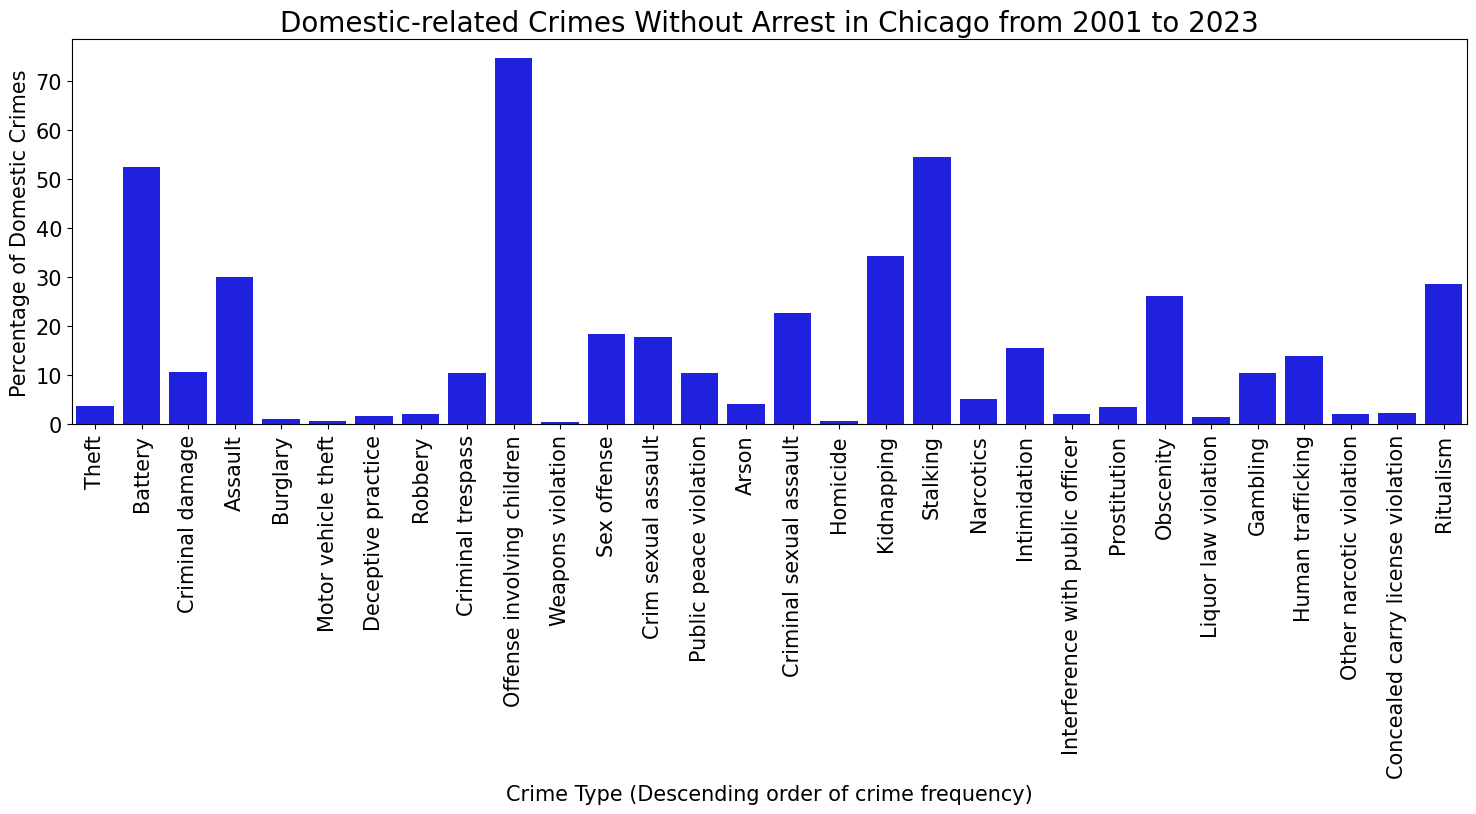

In [493]:
# Using the same dataframe, we can create a plot showing the fraction of arrests for each crime category
fig = plt.figure(figsize=(18, 5))

# Normalizing results
q1df["crime_freq"] = q1df.groupby("primary_type")["counts"].transform(lambda x:x.sum())
q1df["percentage"] = q1df["counts"].mul(100.0).divide(q1df["crime_freq"])
q1df["primary_type"] = q1df["primary_type"].apply(lambda x: x.capitalize())
norm_df = q1df[q1df["domestic"] == True]
norm_df = norm_df.sort_values(by="crime_freq", ascending=False)
# Standard sns barplot
ax = sns.barplot(x="primary_type", y="percentage", data=norm_df, color="b")
# Adding context to the plot
plt.xticks(rotation=90, fontsize=15)
plt.yticks(fontsize=15)
plt.xlabel("Crime Type (Descending order of crime frequency)", fontsize=15)
plt.ylabel("Percentage of Domestic Crimes", fontsize=15)
plt.title("Domestic-related Crimes Without Arrest in Chicago from 2001 to 2023", fontsize=20)
plt.show()

Your graph should look like the graph below:

<img src="./graph.png" />

In [498]:
# Now we can save this file in our submission subdirectory
# Note you are submitting results of your original query not processed dataframe
out_filepath = os.path.join("sub", "crime_arrests.csv")
df.to_csv(out_filepath, index=False)

<img src="./icons/save.png" width="20px" height="20px" align="left"> Check your `sub` (submission) subdirectory to verify that you have a file named `crime_arrests.csv`.

## Q2 (20%)

<img src="./icons/edit.png" width="20px" height="20px" align="left"> For each location category (column `location_description`) find the most frequent district handling that crime. Your final results (in the CSV) should have three columns `location_description`, `district`, `counts`. Where `location_description` is the category for different locations such as streets, residence, etc., `district` is the most frequent district handling that location category and `counts` is simply the number of records associated with that crime. Exclude "OTHER OFFENSE", all non-criminal types and null values of `location-description`. Only consider records until the end of year 2023 and sort results in ascending order by `location_description`.

It would be simpler to first extract relevant counts using SQL and then find the most frequent one for each block using `pandas` but some SQL experts might be able to do it in a single SQL query.

In [449]:
%%bigquery q2df

#standardSQL
-- Write your query below this line


SELECT
    location_description, 
    district,
    COUNT (*) AS counts
FROM
    bigquery-public-data.chicago_crime.crime
WHERE
    primary_type != 'OTHER OFFENSE' 
    AND primary_type NOT LIKE '%NON%CRIMINAL%'
    AND year <= 2023
    AND location_description IS NOT NULL 
    AND district IS NOT NULL
GROUP BY
    location_description, 
    district
ORDER BY
    location_description ASC, 
    district ASC;

Query is running:   0%|          |

Downloading:   0%|          |

In [501]:
q2df = (
    q2df
    .sort_values(by=['location_description', 'counts', 'district'], ascending=[True, False, False])
    .groupby('location_description')
    .first()
    .reset_index()
)

In [503]:
# Let us see a subset of results
q2df.head(10)

,location_description,district,counts
0,ABANDONED BUILDING,7,1961
1,AIRCRAFT,16,654
2,AIRPORT BUILDING NON-TERMINAL - NON-SECURE AREA,16,961
3,AIRPORT BUILDING NON-TERMINAL - SECURE AREA,16,538
4,AIRPORT EXTERIOR - NON-SECURE AREA,16,832
5,AIRPORT EXTERIOR - SECURE AREA,16,364
6,AIRPORT PARKING LOT,16,820
7,AIRPORT TERMINAL LOWER LEVEL - NON-SECURE AREA,16,2158
8,AIRPORT TERMINAL LOWER LEVEL - SECURE AREA,16,735
9,AIRPORT TERMINAL MEZZANINE - NON-SECURE AREA,16,86


In [505]:
# Now we can save this file in our submission subdirectory
out_filepath = os.path.join("sub", "freq_crime.csv")
q2df.to_csv(out_filepath, index=False)

<img src="./icons/save.png" width="20px" height="20px" align="left"> Check your `sub` (submission) subdirectory to verify that you have a file named `freq_crime.csv` following the format specified above.

## Part 2: Google Looker Studio

In this part, we will explore a  tool called [Google Looker Studio](https://datastudio.google.com) which allows us to create visualizations using large scale datasets. This tool can retrieve data from many sources (including BigQuery tables!) and provide a simple interface to create dynamic and sophisticated visualizations. Let's get started!


## Q3 (15%)

Credit will be awarded based on completion of this tutorial. We will try to replicate the graph we created earlier in **Q1**.

First, we need to create **a new (blank) report**, use your last name as the name of report with a suffix `-q3`, if your are working in group then the report name should be of the format `lastname1-lastname2-q3`.


You will be directed to the following screen after report is created. Select BigQuery as the data source.
<img src="./screenshots/dstudio/00-select-bquery-data.png"/>


Select the crime table from chicago_crime public dataset and click *Add* button.

<img src="./screenshots/dstudio/01-select-chicago-crime-data.png"/>


This will take you to add data interface with a default chart. Delete the chart and rename the report as instructed earlier. 

<img src="./screenshots/dstudio/02-rename-report.png"/>


Now that we have a data source added to the report, we can use it to create charts. Click *Add a chart* dropdown menu and select *100% stacked column chart* from it as shown below.


<img src="./screenshots/dstudio/03-add-chart.png"/>

Once, the chart is added, you can click on the chart to view Chart configurations in the right sidebar. Under *DATA*, we can configure fields and under *STYLE*, we can configure appearances of the chart. Setup the fields as shown in the figure below:

<img src="./screenshots/dstudio/04-stacked-100-chart.png"/>

Here, *Dimension* is the variable on the x-axis, *Breakdown Dimension* is the same as *hue* in seaborn. *Metric* specifies how you are going to aggregate records and *Sort* is just sorting on the x-axis. Something seems missing in this graph (can you spot it?)

Now, we need to use correct filters. Click on *ADD A FILTER* shown in the following image.

<img src="./screenshots/dstudio/05(0)-filter.png"/>

Now, setup the appropriate filters as shown below:

<img src="./screenshots/dstudio/05-filter.png"/>


The graph we created earlier had a lot more bars than this one and this is because, by default, it only shows a subset of data. Let us fix that under the *STYLE* menu by setting *Bars* to a large number (200).


<img height="400" width="250" src="./screenshots/dstudio/06-chart-style-bars.png"/>


That should fix the bars, but we also want to label our axes. We can also do that in the *STYLE* menu by checking these boxes:

<img height="400" width="250" src="./screenshots/dstudio/06-chart-style-labels.png"/>


Now we can see all crime types and the axis labels but the labels are not very readable, we can change them as follows:

<img src="./screenshots/dstudio/07(0)-rename-labels.png"/>
<img src="./screenshots/dstudio/07-rename-labels.png"/>


Our graph is now almost ready, we can add title using *Text* tool from the toolbar and we can drag inner boundary (signified by dashed orange line in the figure below) to make our x-axis labels more visible. We can drag the external boundaries to stretch the graph and voila, with just a few clicks, we managed to create this graph from a large dataset.

<img src="./screenshots/dstudio/08-title-context.png"/>


### Submission

<img src="./icons/save.png" width="20px" height="20px" align="left"> Take a screenshot (full screen, PNG format), rename it as `q3-tutorial.png` and store it in `sub` subdirectory.

<img src="./icons/warning.png" width="20px" height="20px" align="left"> Make sure that the report name and graph is visible in the screenshot, no credit will be awarded otherwise.

<img src="./icons/edit.png" width="20px" height="20px" align="left"> Include screenshot in the notebook by editing the following markdown (if needed). It shows as a broken image by default if screenshot is unavailable.

<img src="sub/q3-tutorial.png" />

<br/>

The report is now ready to be shared. Click the *Share* icon and get a Shareable link similar to Google docs:

<img src="./screenshots/dstudio/09-share.png" width="400" height="200" />


<img src="./icons/edit.png" width="20px" height="20px" align="left"> Copy the sharable link to report from the previous step into the box below. Anyone within the University of Illinois should be able to view this report without having to explicity request access. Note that if you redeemed your credits with a non-UIC email, then in this step you would need to share with "Anyone with the link," in order for us to be able to see it.

<img src="./icons/warning.png" width="20px" height="20px" align="left"> No credit will be awarded without this link. Test this link in incognito mode of the browser.

<img src="./icons/warning.png" width="20px" height="20px" align="left"> DO NOT change/delete the report after submission.

[ YOUR LINK HERE ]

https://lookerstudio.google.com/reporting/f63d52d9-234b-439d-8ff7-eca98a8bc8a7

## Q4 (20%)

This question is more open ended and similar to Q2.2-Q2.4 from *HW2*. It will be graded in the same way, based on the completeness of the report produced and the insights you gained from it.  We will be using the publicly avaialable chicago crimes dataset for this task and you are only required to produce a single graph.

Be sure to consider transformations, subsets, correlations, reference markers, and lines/curves-of-best-fit (as covered in Chapter 11 of LDS) to reveal the relationship that you are wanting to learn more about.  Also be sure to make plots that are appropriate for the variable types.  For completeness, be explicit about any assumptions you make in your analysis.  An exemplary plot will have:

* A title
* Labelled and appropriately scaled axes
* A legend, if applicable
* A carefully selected color scheme
* A main point, accentuated through design choices


First, same as **Q3**, you need to create a new (blank) report, use your last name as the name of report with a suffix `-q4`, if your are working in group then the report name should be of the format `lastname1-lastname2-q4`.

<img src="./icons/warning.png" width="20px" height="20px" align="left"> No credit will be awarded if the report name is wrong.


<img src="./icons/warning.png" width="20px" height="20px" align="left"> Do not use the same report that you used in **Q3**

### Submission


<img src="./icons/edit.png" width="20px" height="20px" align="left"> Write your main takeaway/hypothesis 5-15 words in the following cell:

[ YOUR MAIN TAKEAWAY HERE]

Crime incidents were much higher and more volatile in the early 2000s, but over time, both the frequency and volatility have reduced.

<img src="./icons/edit.png" width="20px" height="20px" align="left"> Write a description 100-150 words following cell explaining your assumptions and what you have found.

[YOUR DESCRIPTION HERE]

The graph analyzes crime incident trends over time, categorized by offense type. It is assumed that each record in the dataset represents a single crime case, and that the "Primary Type" field accurately reflects the main nature of each incident. Additionally, it is assumed that reporting practices have remained relatively consistent, although some variations might be due to changes in data collection methods over the years. The analysis shows a noticeable overall decline in crime incidents from 2001 to 2025, with Theft and Battery consistently being the most reported offenses. In the early 2000s, incident counts were highly volatile, with frequent sharp increases and decreases, but after 2010, the trends became more stable and less erratic. This suggests potential improvements in public safety measures or external factors like policy changes. Recent years, particularly after 2020, show lower overall crime frequency, possibly influenced by broader societal changes.


<img src="./icons/save.png" width="20px" height="20px" align="left"> Take a screenshot (full screen, PNG format), rename it as `q4-report.png` and store it in `sub` subdirectory.

<img src="./icons/warning.png" width="20px" height="20px" align="left"> Make sure that the report name and graph is visible in the screenshot, no credit will be awarded otherwise.

<img src="./icons/edit.png" width="20px" height="20px" align="left"> Include screenshot in the notebook by editing the following markdown (if needed). It shows as a broken image by default if screenshot is unavailable.



<img src="sub/q4-report.png" />

<br/>

<img src="./icons/edit.png" width="20px" height="20px" align="left"> Create a sharable link to this report using the process shown in **Q3** and add it in the next cell. Anyone within the university should be able to view this report without having to explicity request access.

<img src="./icons/warning.png" width="20px" height="20px" align="left"> No credit will be awarded without this link. Test this link in incognito mode of the browser.

<img src="./icons/warning.png" width="20px" height="20px" align="left"> DO NOT change/delete the report after submission.

[ YOUR LINK HERE ]

https://lookerstudio.google.com/reporting/633d4f55-0761-4efb-b99a-eb6efe3c8ddc

## Part 3: Google Cloud Vertex AI

In this part, we will use [Vertex AI](https://cloud.google.com/vertex-ai/docs/) to train and deploy a machine machine learning model. Training models from large datasets is a particularly tedious task, especially if it involves hyper-parameter tuning and training may take days to complete and require high computational powers and multiple CPUs/GPUs/TPUs. Vertex AI addressess all these problems by offering everything you need to build and use generative AI—from AI solutions, to Search and Conversation, to foundation models, to a unified AI platform. Specifically, we will use [AutoML](https://cloud.google.com/vertex-ai/docs/beginner/beginners-guide) to easily create a classifier model. So, let's get started with `Vertex AI`!


## Q5 (20%)

Credit will be awarded based on completion of this tutorial. Same, as before, we will train our model using tweets dataset from *HW3* and make predictions on the test set, however we will do all that using Google Cloud Vertex AI.

Twitter data is extracted using [this](https://dev.twitter.com/overview/api) api. The data contains tweets posted by the following six Twitter accounts: `realDonaldTrump, mike_pence, GOP, HillaryClinton, timkaine, TheDemocrats`

For every tweet, there are two pieces of information:
- `screen_name`: the Twitter handle of the user tweeting and
- `text`: the content of the tweet.

The tweets have been divided into two parts - train and test available to you in CSV files. For train, both the `screen_name` and `text` attributes were provided but for test, `screen_name` is hidden.

The overarching goal of the problem is to "predict" the political inclination (Republican/Democratic) of the Twitter user from one of his/her tweets. The ground truth (i.e., true class labels) is determined from the `screen_name` of the tweet as follows
- `realDonaldTrump, mike_pence, GOP` are Republicans
- `HillaryClinton, timkaine, TheDemocrats` are Democrats

Thus, this is a binary classification problem.

The code to create features from data and to create labels is provided below, you do not need to re-write it. Run the following cells to generate data in a [format](https://cloud.google.com/vertex-ai/docs/tabular-data/classification-regression/prepare-data) that Vertex AI can understand.

<img src="./icons/warning.png" width="20px" height="20px" align="left"> DO NOT change this code or use code from *HW3*


In [158]:
def create_labels(processed_tweets):
    return (~processed_tweets['screen_name'].isin(['realDonaldTrump', 'mike_pence', 'GOP'])).astype(int).values

In [159]:
def setup_traintest():
    # Setup training and testing paths
    train_path = os.path.join('data', 'tweets_train.csv')
    train_gcinput_path = os.path.join('data', 'train_gcinput.csv')

    test_path = os.path.join('data', 'tweets_test.csv')
    test_gcinput_path = os.path.join('data', 'test_gcinput.json')

    # Setup vectorizer and PCA
    eng_stopwords = list(set(stopwords.words('english')))
    vec = TfidfVectorizer(stop_words=eng_stopwords, max_df=0.8, min_df=3, max_features=5000)
    pca = PCA(n_components=300)


    # Setup training data
    train_df = pd.read_csv(train_path)
    train_feat = vec.fit_transform(train_df['text'])
    train_feat = pca.fit_transform(train_feat.toarray())
    train_lab = create_labels(train_df)
    df_feat = pd.DataFrame(train_feat)
    df_lab = pd.DataFrame(train_lab)
    df = pd.concat([df_lab, df_feat], axis=1)
    cols = ["label"] + [f"feat_{i}" for i in range(1, 301)]
    df.columns = cols
    df.to_csv(train_gcinput_path, index=False)
    # Setup testing data
    test_df = pd.read_csv(test_path)
    test_feat = vec.transform(test_df['text']).toarray()
    test_feat = pca.transform(test_feat)
    df = pd.DataFrame(test_feat)
    def online_prediction_format(row):
        key = row.name
        value = str(row.values.tolist()).replace("[", "").replace("]","")
        instance = {'key':str(key), 'csv_row':value}
        return instance
    def online_prediction_format(row):
        key = row.name
        features = {f'feat_{i+1}': str(val) for i, val in enumerate(row.values)}
        return {'key': str(key), **features}
    instances = df.apply(lambda x: online_prediction_format(x), axis=1).tolist()

    with open(test_gcinput_path, 'w') as f:
        json.dump({'instances': instances}, f)

In [160]:
setup_traintest()

This code should produce two files `train_gcinput.csv` and `test_gcinput.json` in the `data` subdirectory. `train_gcinput.csv` contains labels in first column and features in remaining columns for each record and `test_gcinput.json` just contains the features and unique key for each record as a JSON instance required by the [prediction](https://cloud.google.com/vertex-ai/docs/predictions/overview) service. There are 300 features for each record.

**Side Note:** PCA is a [dimensionality reduction algorithm](https://medium.com/@mayur87545/dimensionality-reduction-1663f960293f) which makes our file size smaller and our computations simpler. 

### Uploading Data to Cloud

Before we can train our algorithm, we need to upload `train_gcinput.csv` to the cloud so that the ML engine can access it. But how do we do that?

In *Part 0*, we created a bucket which makes it easier to store files on the cloud and enables different Google Cloud services to access those files. You can think of buckets as folders and all the services on cloud as applications which have access to these folders.


Go to [Google Cloud Console](https://console.cloud.google.com/) and you should be able to see *Storage* under *Resources* card on project *Dashboard*. Click on it and it will take you to *Storage Buckets*. Select your bucket that you have created before and upload `train_gcinput.csv` in the root of the bucket. Create a new subdirectory in the root of the bucket and name it as `output`, we will use it later to store logs and trained model. It should like the following figure:

<img src="./screenshots/mlengine/01-upload-files.png" />


### Creating the Dataset

To train the model, we first need to create a dataset and use the Google Cloud console to associate our prepared data into the dataset. Go to [Google Cloud Console](https://console.cloud.google.com) and from the sidebar, select *Vertex AI > Datasets* as shown in the following figure.

<img height="500" width="500" src="./screenshots/mlengine/02-select-jobs.png" />


If you have not used *Vertex AI* before then you first need to Enable API to use this service. Click *Enable* (it might take a while).

<img src="./screenshots/mlengine/03-enable-api.png" />

On the datasets page, select *Create* to create a new dataset.

<img src="./screenshots/mlengine/04-create-dataset.png" />

In the dataset setup, update the settings following the format provided in the figure below, ensuring that the dataset is tabular and for classification. Once done, click on *create*.

<img src="./screenshots/mlengine/04-dataset-info.png" />

On the following page, we will need to associate this newly created tabular dataset with the data from our bucket. Once we have selected the `train_gcinput.csv` file from the cloud storage, we can go ahead and complete the dataset creation.

<img src="./screenshots/mlengine/04-dataset-source.png" />

### Training the Model

Now, we have all the files necessary to train our model. From the sidebar, select *Training* under *Model Development* as shown in the following figure. 

<img src="./screenshots/mlengine/05-train-menu.png" />

Let's train a new model on our dataset to learn how to classify tweet data.

<img src="./screenshots/mlengine/05-train-menu-2.png" />

The following menu should already be filled with the desired settings, so click on *continue*.

<img src="./screenshots/mlengine/05-train-menu-3.png" />

Select *label* as the target column for our classifier model. The data is already split with the desired ratio. The validation data is used while training the model for hyper-parameter tuning and we will also use 10% of the training data as Test data for model evaluation. Note that this is not the final test data that we will be using for predictions. Then, click on *continue*.

<img src="./screenshots/mlengine/05-train-menu-4.png" />

Skip the *Join Featurestone* page and continue to the *Training Options* page. In the advanced options at the bottom of this next page, select AUC ROC as the optimization objective. Then, click on *continue*.

<img src="./screenshots/mlengine/05-train-menu-5-1.png" />

In the final page, select the maximum number of node hours to 1, making sure that *Enable early stopping* is active. We can then finally start training our model by clicking on *Start Training*.

<img src="./screenshots/mlengine/05-train-menu-5.png" />

Your training should now be up and running now and you should be able to see a list of running jobs:

<img src="./screenshots/mlengine/05-train-menu-6.png" />

You can open a job by clicking on the pipeline name. This will take you to the job progress page (shown below) where you can monitor the training progress. Note that the model training could take a few hours to complete, be patient!

## Evaluation Metrics and Model Deployment
Now that our model is trained, we can see on the same page the performance by clicking on the ID of the evaluation (which is automatically performed) as shown in the figure below. 

<img src="./screenshots/mlengine/06-completed.png" />

Once we are satisfied with the evaluation, we can deploy the model for online or batch prediction by clicking on *Deploy & Test* as shown on the figure above.

<img src="./screenshots/mlengine/07-evaluation.png" />

We will deploy our model within an endpoint API, which will be made available on Google Cloud. This makes it useful to send timely requests to the trained model in order to perform online prediction of data. For begin this final step, click on *Deploy to endpoint*.

<img src="./screenshots/mlengine/08-deploy.png" />

In the deploy menu, give a meaningful name to the endpoint for our model. Then, click *continue*.

<img src="./screenshots/mlengine/08-deploy-menu.png" />

In the following page, most of the settings are already the desired ones by default. 

<img src="./icons/warning.png" width="20px" height="20px" align="left"/> Be sure to set the maximum number of compute nodes to 1 to reduce the expenses for executing our model. Similarly, select *n1-standard-2, 2 vCPUs, 7.5 GiB memory* as the machine type. 

Then, press *continue*.

<img src="./screenshots/mlengine/08-deploy-menu-2.png" />

In the final page, disable model monitoring and then click on *Deploy* to create the endpoint.

<img src="./screenshots/mlengine/08-deploy-menu-3.png" />

It will take you to your model page, your model is now being deployed, wait for the green check to appear next to version before you proceed.

<img src="./screenshots/mlengine/09-endpoint-list.png" />


Your model is now deployed on the cloud and can be used to make predictions by connecting to the endpoint through its ID. Be sure to copy it for the following steps.

### Making Predictions

We can either use our local machine to make calls to the Google Cloud and make predictions using gcloud command from [Google Cloud SDK](https://cloud.google.com/sdk/docs/) or we can use [Google Cloud Shell](https://cloud.google.com/shell/) which comes with Google Cloud SDK. We will use *Google Cloud Shell* in this tutorial.

Visit [Google Cloud Console](https://console.cloud.google.com) and click on *Activate Cloud Shell* icon in the top bar as shown in the following screenshot. If you have Cloud Shell already open, click "+" icon to open a new Shell tab.

<img src="./screenshots/cloudshell/01-open-shell.png" />

This should open a terminal in the browser and this is just like a regular linux terminal, you can give a command `ls` to see which files are there. Now, we can upload files to this terminal using the menu on top-right of the terminal window. We need to upload `homework4-key.json` file that we downloaded earlier and `test_gcinput.json` file from `data` directory.

<img src="./screenshots/cloudshell/02-upload-files.png" />

Once the files are uploaded you can verify success using `ls` command.

<img src="./screenshots/cloudshell/03-list-files.png" />

Now, you can run the following command to enable authentication using the key

```
export GOOGLE_APPLICATION_CREDENTIALS=homework4-key.json
```

Once, the authentication is enabled, you can use the following `gcloud` command to make predictions using the endpoint ID from the previous step:


```
gcloud ai endpoints predict <endpoint ID> --region=us-central1 --json-request=test_gcinput.json
```

If everything goes right, then you should be able to see the following output. Here, *CLASSES* are just binary class labels 0/1 and *scores* shows the probability of being in that class.

<img src="./screenshots/cloudshell/04-pred-output.png" />

Let us save these results in JSON format using this command.


```
gcloud ai endpoints predict <endpoint ID> --region=us-central1 --json-request=test_gcinput.json --format=json > results.json
```

This should create a file `results.json` in current directory. You can view the produced JSON using this command:

```
cat results.json
```

<img src="./icons/save.png" width="20px" height="20px" align="left"> Select *Download File* from the top-right menu and save `results.json` in your `sub` (submission) subdirectory and that's it!

## Before Submitting

<img src="./icons/save.png" width="20px" height="20px" align="left"> Make sure that you have all the required screenshots and data files in `sub` subdirectory signified by this icon.

<img src="./icons/edit.png" width="20px" height="20px" align="left"/> Make sure that you have made all necessary additions to the notebook signified by this icon.

<img src="./icons/warning.png" width="20px" height="20px" align="left"/> Make sure that you have read all the warnings.


Finally,


<img src="./icons/warning.png" width="20px" height="20px" align="left"> Once the homework is fully graded, you may remove your project from Google cloud or stop any services to avoid running expenses. Most likely there will be no running expenses even if you do not stop/remove the project but it is usually not recommended to keep unecessary components running on Google Cloud as it may incur additional cost.

<img src="./icons/warning.png" width="20px" height="20px" align="left"> Before submitting written part of the HW, make sure that all parts of your solution are completely visible, pay special attention to the images you have included.

### Part 4: Statement on the use of AI tools (5%)

You're almost done! Next, document your use of AI tools.

Did you use any AI tools, such as ChatGPT, in the completion of this homework? 

[Yes/No]


YES


If you did, document **THOROUGHLY** which tools and how you used them. For each part of the homework that you used them, specify what prompts you used, whether you were satisfied with the tool's answer and whether you modified the tool's answer. \
NOTE: Not providing a complete answer will likely **NOT** earn you full credits for this question.

[Your answer here]


For this homework, I used OpenAI's ChatGPT (GPT-4o version) to assist with multiple stages of the analysis, visualization, and write-up. Below, I document in detail how and where I used the tool:
1. SQL Query Generation: "In SQL, how do I write a query that counts cases based on two boolean categories like 'domestic' and a categorical field like 'primary_type'? Also, how can I exclude specific values like 'OTHER OFFENSE'?"
2. Looker Studio Visualization Guidance: "How can I build a time series visualization in Looker Studio using a date field?", "In Looker Studio, what is the best way to restrict a time series chart to a single year?",
"How do I create a calculated field to extract year or month from a timestamp field?", 
3. Title Suggestions for Visualization: "Suggest a few descriptive titles for a time series graph showing crime incidents types in a time period."
4. Main Takeaway and Description Writing: "Help me write a paragraph summarizing assumptions and trends seen in a time series crime location analysis."


## Submission
As instructed earlier on the top of this notebook, submit all files in the `sub` directory and `hw4.ipynb` file to `Homework4 - code` assignment in the Gradescope. Similarly, submit the exported PDF hw4.pdf to `Homework4 - written` assignment in the Gradescope. Make sure all the images you added are clearly visible, the links are not broken, code is not truncated, and answers are marked appropriately.